# Why Avoiding Big Losses Matters More Than Big Gains

*Street Smart Finance · The Analytical Investor · Year 1, Month 9*

**Read the article:** [Why Avoiding Big Losses Matters More Than Big Gains](https://analytical-investor.blog/?p=1022)

The arithmetic behind the article: the gain needed to recover from a loss, and Steady versus Flashy over six years.

> Run locally with `pip install -e ".[notebooks]"` from the repo root, then open this notebook in Jupyter. All data is simulated with fixed seeds, so every number matches the article.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9, 5), "axes.grid": True, "grid.alpha": 0.3})

## The recovery table

lose 10% -> need 11% to get back to even
lose 25% -> need 33% to get back to even
lose 50% -> need 100% to get back to even
lose 80% -> need 400% to get back to even


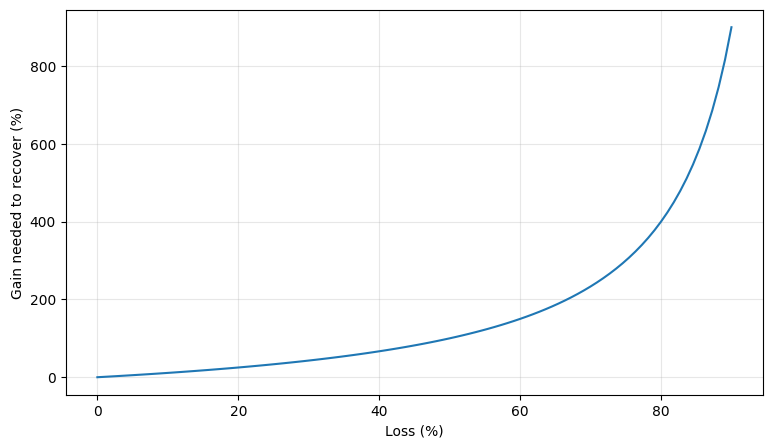

In [2]:
from analytical_investor.returns import recovery_gain_needed
for loss in (0.10, 0.25, 0.50, 0.80):
    print(f"lose {loss:.0%} -> need {recovery_gain_needed(loss):.0%} to get back to even")
losses = np.linspace(0, 0.9, 100)
plt.plot(losses * 100, [recovery_gain_needed(x) * 100 for x in losses])
plt.xlabel("Loss (%)"); plt.ylabel("Gain needed to recover (%)"); plt.show()

## Steady vs Flashy

Average return: Steady 8.0%, Flashy 12.5%
Final wealth:   Steady 1.59, Flashy 1.32


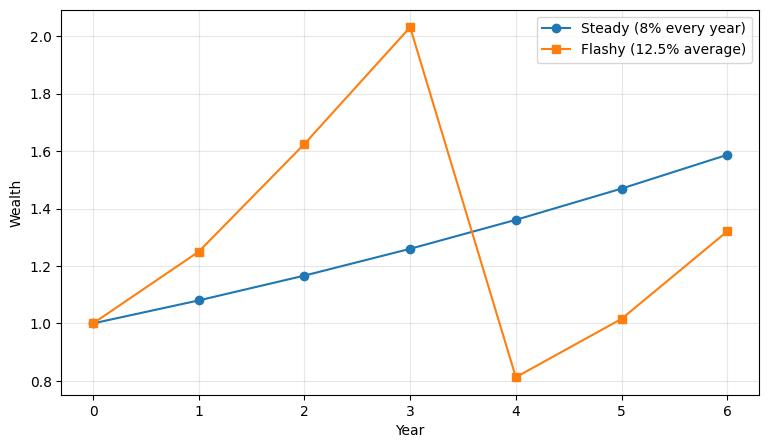

In [3]:
steady = np.full(6, 0.08)
flashy = np.array([0.25, 0.30, 0.25, -0.60, 0.25, 0.30])
print(f"Average return: Steady {steady.mean():.1%}, Flashy {flashy.mean():.1%}")
print(f"Final wealth:   Steady {np.prod(1 + steady):.2f}, Flashy {np.prod(1 + flashy):.2f}")
years = np.arange(7)
plt.plot(years, np.r_[1, np.cumprod(1 + steady)], "o-", label="Steady (8% every year)")
plt.plot(years, np.r_[1, np.cumprod(1 + flashy)], "s-", label="Flashy (12.5% average)")
plt.xlabel("Year"); plt.ylabel("Wealth"); plt.legend(); plt.show()